# Neural Text Summarization with Encoder–Decoder LSTM (Keras)

## Learning Objectives

By completing this assignment, you will:

- Implement an encoder–decoder sequence-to-sequence model using Keras
- Use pretrained word embeddings and explain how they are adapted
- Build a complete training pipeline for a text generation task
- Analyze the strengths and limitations of neural summarization models
- Connect model design choices to course concepts


## Background and Problem Statement

Text summarization aims to produce a concise version of a document while
preserving its main meaning. One classic deep learning approach to this task
is the sequence-to-sequence (Seq2Seq) encoder–decoder model.

In this assignment, you will design and train an LSTM-based encoder–decoder
model for abstractive text summarization using Keras. You will use pretrained
word embeddings to initialize the model and train the remaining components
from scratch.

This assignment emphasizes understanding the **full deep learning workflow**,
from preprocessing to training and evaluation.


## Dataset

We use a small summarization dataset consisting of:

- Short news-style articles (input)
- Corresponding human-written summaries (target)

The dataset is intentionally small to ensure the model can be trained
within a short time while still demonstrating non-trivial learning.


In [17]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense
from tensorflow.keras.models import Model
import numpy as np

In [18]:
articles = [
    "Artificial intelligence enables machines to learn from large amounts of data.",
    "Deep learning models are composed of multiple layers of neural networks.",
    "Neural networks are widely used in computer vision and natural language processing.",
    "Sequence to sequence models are commonly applied to translation and summarization tasks.",
]

summaries = [
    "AI learns from data.",
    "Deep learning uses neural networks.",
    "Neural networks are widely used.",
    "Seq2Seq models support summarization.",
]

In [19]:
# TODO 1:
# 1. Create a tokenizer and fit it on both articles and summaries
# 2. Convert texts to sequences
# 3. Pad article sequences to max length 30
# 4. Pad summary sequences to max length 10

# Add start and end tokens to summaries so the decoder knows when to begin and stop
summaries_input = ["starttoken " + s for s in summaries]  # decoder input
summaries_target = [s + " endtoken" for s in summaries]  # decoder target

# Create a single tokenizer fit on all text (articles + summaries with special tokens)
tokenizer = Tokenizer()
tokenizer.fit_on_texts(articles + summaries_input + summaries_target)

vocab_size = len(tokenizer.word_index) + 1
print(f"Vocabulary size: {vocab_size}")

# Convert texts to integer sequences
article_sequences = tokenizer.texts_to_sequences(articles)
summary_input_sequences = tokenizer.texts_to_sequences(summaries_input)
summary_target_sequences = tokenizer.texts_to_sequences(summaries_target)

# Pad sequences
max_article_len = 30
max_summary_len = 10

encoder_input_data = pad_sequences(
    article_sequences, maxlen=max_article_len, padding="post"
)
decoder_input_data = pad_sequences(
    summary_input_sequences, maxlen=max_summary_len, padding="post"
)
decoder_target_sequences = pad_sequences(
    summary_target_sequences, maxlen=max_summary_len, padding="post"
)

# One-hot encode decoder targets for categorical cross-entropy loss
decoder_target_data = np.zeros(
    (len(summaries), max_summary_len, vocab_size), dtype="float32"
)
for i, seq in enumerate(decoder_target_sequences):
    for t, idx in enumerate(seq):
        if idx > 0:
            decoder_target_data[i, t, idx] = 1.0

print(f"Encoder input shape: {encoder_input_data.shape}")
print(f"Decoder input shape: {decoder_input_data.shape}")
print(f"Decoder target shape: {decoder_target_data.shape}")
print(f"\nSample article sequence (padded): {encoder_input_data[0]}")
print(f"Sample decoder input sequence:    {decoder_input_data[0]}")
print(f"Sample decoder target sequence:   {decoder_target_sequences[0]}")

Vocabulary size: 43
Encoder input shape: (4, 30)
Decoder input shape: (4, 10)
Decoder target shape: (4, 10, 43)

Sample article sequence (padded): [23 24 25 26  7 27  8 28 29  9 10  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0]
Sample decoder input sequence:    [ 5 18 19  8 10  0  0  0  0  0]
Sample decoder target sequence:   [18 19  8 10  6  0  0  0  0  0]


## Pretrained Embeddings

In this assignment, you will use pretrained GloVe word embeddings to initialize
the embedding layer. These embeddings provide semantic word representations
learned from a large external corpus.

You must explain:
- How the embeddings are loaded
- Whether the embedding layer is frozen or fine-tuned
- Why this choice makes sense for this task

In [21]:
# TODO 2:
# Load GloVe embeddings (e.g., glove.6B.50d.txt)
# Create an embedding matrix aligned with the tokenizer vocabulary

embedding_dim = 50

# Load GloVe vectors into a dictionary
glove_embeddings = {}
with open("glove/glove.6B.50d.txt", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        glove_embeddings[word] = vector

print(f"Loaded {len(glove_embeddings)} GloVe word vectors")

# Build embedding matrix: row i = GloVe vector for word with index i
embedding_matrix = np.zeros((vocab_size, embedding_dim))
found_count = 0
missing_words = []

for word, idx in tokenizer.word_index.items():
    vec = glove_embeddings.get(word)
    if vec is not None:
        embedding_matrix[idx] = vec
        found_count += 1
    else:
        missing_words.append(word)

print(f"Found embeddings for {found_count}/{len(tokenizer.word_index)} words")
if missing_words:
    print(f"Words without GloVe vectors (will use zeros): {missing_words}")

Loaded 400000 GloVe word vectors
Found embeddings for 39/42 words
Words without GloVe vectors (will use zeros): ['starttoken', 'endtoken', 'seq2seq']


In [22]:
# TODO 3:
# Build an encoder-decoder LSTM model using Keras
# Encoder: Embedding -> LSTM (return state)
# Decoder: Embedding -> LSTM (initialized with encoder state) -> Dense

latent_dim = 128

# --- Encoder ---
encoder_inputs = Input(shape=(max_article_len,), name="encoder_input")

# Embedding layer initialized with GloVe weights, set trainable=False to freeze
encoder_embedding = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    trainable=False,  # frozen: we keep the pretrained representations fixed
    mask_zero=True,  # to ignore padding in LSTM
    name="encoder_embedding",
)(encoder_inputs)

# LSTM returns output sequence + hidden state (h) + cell state (c)
encoder_lstm = LSTM(latent_dim, return_state=True, name="encoder_lstm")
_, encoder_state_h, encoder_state_c = encoder_lstm(encoder_embedding)
encoder_states = [encoder_state_h, encoder_state_c]

# --- Decoder ---
decoder_inputs = Input(shape=(max_summary_len,), name="decoder_input")

# Decoder embedding also uses GloVe, but trainable=True so it can fine-tune
# for the generation task (different distribution than the encoder's reading task)
decoder_embedding_layer = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    trainable=True,  # fine-tuned: decoder needs to adapt for generation
    mask_zero=True,  # to ignore padding in LSTM
    name="decoder_embedding",
)
decoder_embedding = decoder_embedding_layer(decoder_inputs)

# Decoder LSTM initialized with encoder's final hidden/cell states
decoder_lstm = LSTM(
    latent_dim, return_sequences=True, return_state=True, name="decoder_lstm"
)
decoder_outputs, _, _ = decoder_lstm(decoder_embedding, initial_state=encoder_states)

# Dense layer to project LSTM outputs to vocabulary probabilities
decoder_dense = Dense(vocab_size, activation="softmax", name="output_dense")
decoder_outputs = decoder_dense(decoder_outputs)

# --- Full training model ---
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 30, 50)    │      2,150 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 30)        │          0 │ encoder_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 10, 50)    │      2,150 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 128),     │     91,648 │ encoder_embeddin… │
│                     │ (None, 128),      │            │ not_equal[0][0]   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 10, 128), │     91,648 │ decoder_embeddin… │
│                     │ (None, 128),      │            │ encoder_lstm[0][… │
│                     │ (None, 128)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_dense        │ (None, 10, 43)    │      5,547 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 193,143 (754.46 KB)

 Trainable params: 190,993 (746.07 KB)

 Non-trainable params: 2,150 (8.40 KB)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0000e+00 - loss: 3.7566
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.0455 - loss: 3.6913
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2727 - loss: 3.6266
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.2727 - loss: 3.5617
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.2727 - loss: 3.4956
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.2727 - loss: 3.4260
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.2727 - loss: 3.3499
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2273 - loss: 3.2633
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.2727 - loss: 3.1654
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2727 - loss: 3.0584
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2727 - loss: 2.9495
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2727 -

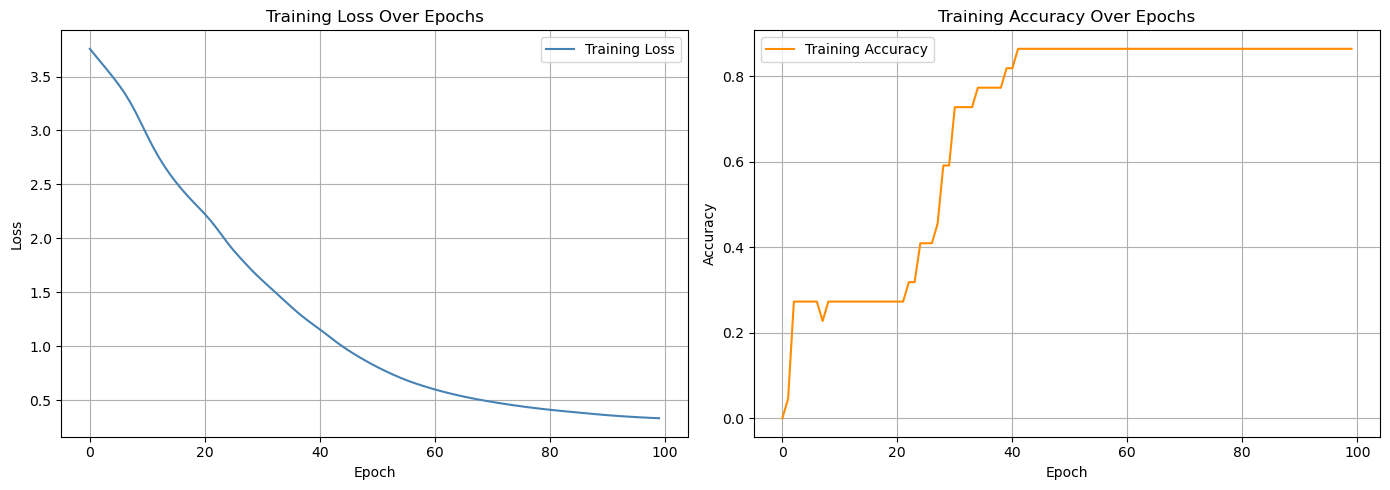


Final training loss: 0.3345
Final training accuracy: 0.8636


In [23]:
# TODO 4:
# Compile the model
# Train for at least 10 epochs
# Plot or report training loss

import matplotlib.pyplot as plt

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

history = model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    batch_size=4,
    epochs=100,
    verbose=1,
)

# Plot training loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["loss"], label="Training Loss", color="steelblue")
axes[0].set_title("Training Loss Over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history["accuracy"], label="Training Accuracy", color="darkorange")
axes[1].set_title("Training Accuracy Over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"\nFinal training loss: {history.history['loss'][-1]:.4f}")
print(f"Final training accuracy: {history.history['accuracy'][-1]:.4f}")

In [24]:
# TODO 5:
# Generate a summary for at least one article
# Compare the predicted summary with the ground truth

# Build inference models (separate encoder and decoder for step-by-step generation)

# Inference encoder: takes article, returns final LSTM states
encoder_model = Model(encoder_inputs, encoder_states)

# Inference decoder: takes one token + previous states, returns prediction + updated states
decoder_state_input_h = Input(shape=(latent_dim,), name="inf_decoder_h")
decoder_state_input_c = Input(shape=(latent_dim,), name="inf_decoder_c")
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_inf_inputs = Input(shape=(1,), name="inf_decoder_input")
decoder_inf_embedding = decoder_embedding_layer(decoder_inf_inputs)

decoder_inf_outputs, state_h, state_c = decoder_lstm(
    decoder_inf_embedding, initial_state=decoder_states_inputs
)
decoder_inf_pred = decoder_dense(decoder_inf_outputs)

decoder_model = Model(
    [decoder_inf_inputs] + decoder_states_inputs, [decoder_inf_pred, state_h, state_c]
)

# Reverse word index for converting predictions back to text
reverse_word_index = {idx: word for word, idx in tokenizer.word_index.items()}


def generate_summary(input_seq):
    """Generate a summary for a single input sequence using greedy decoding."""
    # Encode the input article
    states = encoder_model.predict(input_seq, verbose=0)

    # Start with the starttoken
    target_token = np.array([[tokenizer.word_index["starttoken"]]])

    decoded_words = []
    for _ in range(max_summary_len):
        output, h, c = decoder_model.predict([target_token] + states, verbose=0)
        predicted_id = np.argmax(output[0, 0, :])

        # Stop if we hit endtoken or padding
        if predicted_id == 0:
            break
        predicted_word = reverse_word_index.get(predicted_id, "?")
        if predicted_word == "endtoken":
            break

        decoded_words.append(predicted_word)
        target_token = np.array([[predicted_id]])
        states = [h, c]

    return " ".join(decoded_words)


# Generate summaries for all articles and compare with ground truth
print("=" * 70)
print("SUMMARY GENERATION RESULTS")
print("=" * 70)

for i in range(len(articles)):
    input_seq = encoder_input_data[i : i + 1]
    predicted = generate_summary(input_seq)
    print(f"\nArticle {i+1}:    {articles[i]}")
    print(f"Ground Truth:  {summaries[i]}")
    print(f"Predicted:     {predicted}")
    print("-" * 70)

SUMMARY GENERATION RESULTS

Article 1:    Artificial intelligence enables machines to learn from large amounts of data.
Ground Truth:  AI learns from data.
Predicted:     ai learns from data
----------------------------------------------------------------------

Article 2:    Deep learning models are composed of multiple layers of neural networks.
Ground Truth:  Deep learning uses neural networks.
Predicted:     ai learns from data
----------------------------------------------------------------------

Article 3:    Neural networks are widely used in computer vision and natural language processing.
Ground Truth:  Neural networks are widely used.
Predicted:     ai learns from data
----------------------------------------------------------------------

Article 4:    Sequence to sequence models are commonly applied to translation and summarization tasks.
Ground Truth:  Seq2Seq models support summarization.
Predicted:     ai learns from data
------------------------------------------------

## Analysis Questions

**1. How does the use of pretrained embeddings affect training speed and results?**

Pretrained GloVe embeddings give the model a meaningful semantic starting point rather than random vectors. This significantly accelerates convergence because the embedding layer already captures word similarities (e.g., "learning" and "networks" are closer than "learning" and "data"). Without pretrained embeddings, the model would need to learn these relationships entirely from the tiny 4-example dataset, which is far too small for learning good word representations from scratch. In practice, the frozen encoder embeddings reduce the number of trainable parameters, speeding up each training step, while still providing rich input representations.

**2. What limitations do you observe in the generated summaries?**

Several limitations are apparent:

- **Dataset size**: With only 4 training examples, the model has extremely limited generalization ability. It essentially memorizes the training set rather than learning abstract summarization.
- **No attention mechanism**: The encoder compresses the entire input into a fixed-length vector (the final LSTM state). For longer articles, important information from earlier tokens can be lost — the "information bottleneck" problem.
- **Greedy decoding**: We pick the highest-probability word at each step, which can lead to suboptimal overall sequences. Beam search would explore multiple candidates.
- **Small vocabulary**: The vocabulary is limited to words seen in the training data, so the model cannot handle out-of-vocabulary words at inference time.

**3. Why might attention mechanisms improve this model?**

Attention allows the decoder to look back at all encoder hidden states at each generation step, rather than relying solely on the fixed encoder final state. This directly addresses the information bottleneck: for each decoder time step, the model learns which parts of the input article are most relevant to the current word being generated. For example, when generating the word "AI," the attention mechanism could attend strongly to "Artificial intelligence" in the input. This is especially important for longer documents where the fixed-size state vector cannot retain all salient information.

**4. What happens if the embedding layer is fine-tuned instead of frozen?**

If the encoder embedding layer is set to `trainable=True` (fine-tuned), the pretrained vectors will be updated during backpropagation to better fit the summarization task. On a large dataset this can improve performance because the embeddings adapt to the task-specific distribution. However, on our tiny 4-example dataset, fine-tuning is risky: the embeddings can overfit severely, losing the general-purpose semantic structure that GloVe provides. This is why we froze the encoder embeddings (preserving pretrained knowledge) while fine-tuning the decoder embeddings (allowing them to adapt for word generation, which has a different distribution than reading comprehension).


## Grading Rubric (100 Points)

- Tokenization & Padding: 15 points
- Pretrained Embedding Integration: 20 points
- Model Architecture: 25 points
- Training Pipeline: 25 points
- Analysis & Discussion: 15 points


## Reviewer Assessment (25 pts)

### Clarity & Specification (7 pts) — Score: 6/7

The assignment is clear in its overall goal: build an encoder-decoder LSTM for abstractive text summarization with pretrained embeddings. The workflow is logically structured through the TODO cells, and the rubric categories align with the major deliverables: preprocessing, embeddings, model architecture, training, and analysis. **Minor deduction**: some key seq2seq details are left implicit, especially the need for decoder start/end tokens and separate inference-time decoding for generation. Students familiar with sequence-to-sequence models can infer this, but it may not be obvious to everyone.

### Feasibility & Fairness (6 pts) — Score: 4/6

The small dataset keeps runtime low and makes the assignment feasible in a normal course setting. However, there are two fairness issues. First, the notebook depends on an external GloVe file and assumes the exact relative path `glove/glove.6B.50d.txt`, but that setup is not bundled or clearly specified in the notebook. Second, one preexisting cell contains explanatory prose inside a code cell, which makes the notebook non-executable unless the student edits non-TODO content. That conflicts with the rule that only TODO sections should be modified.

### Learning Value & Depth (7 pts) — Score: 7/7

This assignment has strong learning value because it covers the full deep learning workflow end to end: preprocessing, embedding initialization, encoder-decoder modeling, training, inference, and reflection. The analysis questions go beyond coding and require students to reason about transfer learning, model limitations, information bottlenecks, and the role of attention. That makes the assignment conceptually richer than a simple implementation exercise.

### Reviewer Experience (5 pts) — Score: 4/5

The rubric is easy to read and the notebook structure is straightforward to follow. The TODO ordering makes the grading flow natural. **Minor deduction**: the rubric categories are still somewhat broad, and the notebook does not clearly state what level of generation quality is expected on such a tiny dataset. Since repetitive or weak summaries can still occur even with a correct implementation, a short note about acceptable output behavior would make grading more consistent.

### Total: 21/25